In [29]:
import pandas as pd
import seaborn as sns
import numpy as np

In [30]:
df=pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
#at=temperature
#v=vaccun
#ap=pressure
#rh=humidity


#pe=produces energy


In [31]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [32]:
x=df.drop("PE",axis=1)
y=df["PE"]


In [33]:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)


In [34]:
df.shape

(9568, 5)

In [35]:

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [37]:
x_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [38]:

import torch
import torch.nn as nn
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [39]:
type(x_train_scaled)

numpy.ndarray

In [40]:
type(y_train)

pandas.core.series.Series

In [41]:

from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)

In [42]:

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [43]:

###Deep learning
#define ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__ ()
        
        self.model=nn.Sequential (
            #1st hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),

            #2nd layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1)
    )
    
    def forward(self,x):
        return self.model(x)

In [44]:

import torch.optim as optim
model=ANN()
#loss,optimizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [48]:

#training the model 
epochs=100
train_losses=[]
val_losses=[]
best_val_loss=float("inf")
for epoch in range(epochs):
    model.train()
    running_loss=0.0 #total training loss for 1 epoch

    for xb,yb in train_loader:
        #xb feature if one batch
        #yb labels of 1 batch
        optimizer.zero_grad() #old mistake reset
        output=model(xb) #predicted output for this batch
        loss=crietrion(output,yb)#compute loss
        loss.backward() #back pop...compute gradients
        optimizer.step() #params update
        running_loss +=loss.item() #loss in tensor value we are converting it to python float
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    #validation
    running_val_loss=0.0  #no gradient compute
    model.eval()
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss +=loss
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)
    print(f"epoch {epoch+1}/{epochs} ==>train loss ={epoch_train_loss} &  varloss={epoch_val_loss}")

    if epoch_val_loss <best_val_loss:
        best_val_loss =epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")  #pt or pth extension to save the file

epoch 1/100 ==>train loss =20.441660495599113 &  varloss=18.771074295043945
epoch 2/100 ==>train loss =20.470216528574625 &  varloss=18.73142433166504
epoch 3/100 ==>train loss =20.541889850298563 &  varloss=18.91404914855957
epoch 4/100 ==>train loss =20.443544427553814 &  varloss=18.97330093383789
epoch 5/100 ==>train loss =20.614439109961193 &  varloss=19.020383834838867
epoch 6/100 ==>train loss =20.673997916777928 &  varloss=18.89325523376465
epoch 7/100 ==>train loss =20.66708830992381 &  varloss=18.63545036315918
epoch 8/100 ==>train loss =20.53499175707499 &  varloss=18.88608169555664
epoch 9/100 ==>train loss =20.47729240655899 &  varloss=18.653959274291992
epoch 10/100 ==>train loss =20.584174382686616 &  varloss=19.625337600708008
epoch 11/100 ==>train loss =20.66342556476593 &  varloss=19.529987335205078
epoch 12/100 ==>train loss =20.42221465408802 &  varloss=18.901466369628906
epoch 13/100 ==>train loss =20.454094890753428 &  varloss=19.091068267822266
epoch 14/100 ==>tra

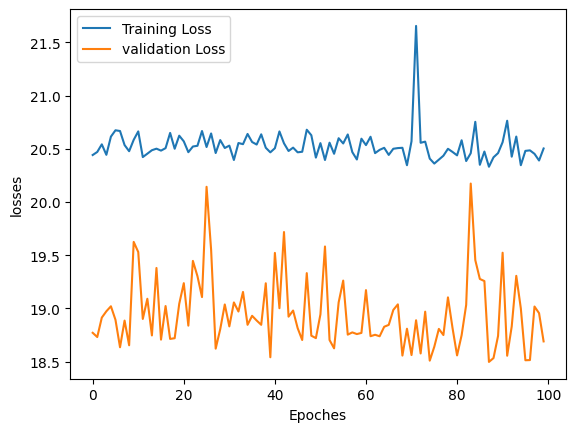

In [49]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({
    "train_loss":train_losses,
    "validation loss":val_losses
})
plt.plot(loss_df["train_loss"],label="Training Loss")
plt.plot(loss_df["validation loss"],label="validation Loss")
plt.xlabel("Epoches")
plt.ylabel("losses")
plt.legend()


In [47]:
#loading teh best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [52]:
#evealuate the model
model.eval()
with torch.no_grad():
    train_pred=model(x_train_tensor)
    test_pred=model(x_test_tensor)

    train_mse_loss=crietrion(train_pred,y_train_tensor)
    test_mse_loss=crietrion(test_pred,y_test_tensor)
print("Training MSE:",train_mse_loss.item())
print("Test MSE:",test_mse_loss.item())

Training MSE: 20.20771598815918
Test MSE: 18.695728302001953


In [55]:
from sklearn.metrics import r2_score
print("r2 score=:",r2_score(y_test,test_pred))


r2 score=: 0.9346632529629714


In [58]:
predicteed_df=pd.DataFrame(test_pred.numpy(),columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])
pd.concat([predicteed_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,434.924011,433.27
1,437.195801,438.16
2,461.606598,458.42
3,477.124817,480.82
4,434.920166,441.41
...,...,...
1909,451.774139,456.70
1910,431.543152,438.04
1911,467.879425,467.80
1912,431.022766,437.14
